Starting simulation at t=0. s for a duration of 2. s
0.35182 s (17%) simulated in 10s, estimated 47s remaining.
0.71052 s (35%) simulated in 20s, estimated 36s remaining.
1.06914 s (53%) simulated in 30s, estimated 26s remaining.
1.42434 s (71%) simulated in 40s, estimated 16s remaining.
1.77384 s (88%) simulated in 50s, estimated 6s remaining.
2. s (100%) simulated in 56s
Saving excitatory spike times to spikesE.txt
Saving inhibitory spike times to spikesI.txt
Saving raster plot to wang2002.pdf


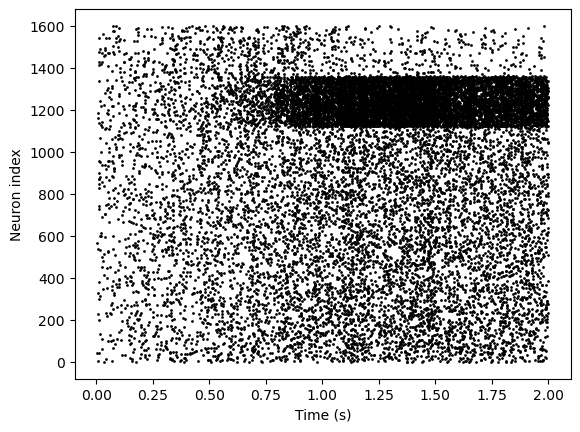

In [1]:
"""
Probabilistic decision making by slow reverberation in cortical circuits.
X-J Wang, Neuron 2002.

http://dx.doi.org/10.1016/S0896-6273(02)01092-9
Edited for Python3 by John, 10/2022
"""
from collections import OrderedDict

from brian2 import *

#=========================================================================================
# Equations
#=========================================================================================

# sAMPA, x, sNMDA, sGABA are synaptic conductances stored pre-synatically
# S_AMPA, S_NMDA, S_GABA are synaptic conductances stored post-synaptically
equations = dict(
    E = '''
    dV/dt         = (-(V - V_L) - Isyn/gE) / tau_m_E : volt (unless refractory)
    Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_E*sAMPA_ext*(V - V_E) : amp
    I_AMPA        = gAMPA_E*S_AMPA*(V - V_E) : amp
    I_NMDA        = gNMDA_E*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = gGABA_E*S_GABA*(V - V_I) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsAMPA/dt     = -sAMPA/tauAMPA : 1
    dx/dt         = -x/tau_x : 1
    dsNMDA/dt     = -sNMDA/tauNMDA + alpha*x*(1 - sNMDA) : 1
    S_AMPA : 1
    S_NMDA : 1
    S_GABA : 1
    ''',

    I = '''
    dV/dt         = (-(V - V_L) - Isyn/gI) / tau_m_I : volt (unless refractory)
    Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA : amp
    I_AMPA_ext    = gAMPA_ext_I*sAMPA_ext*(V - V_E) : amp
    I_AMPA        = gAMPA_I*S_AMPA*(V - V_E) : amp
    I_NMDA        = gNMDA_I*S_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = gGABA_I*S_GABA*(V - V_I) : amp
    dsAMPA_ext/dt = -sAMPA_ext/tauAMPA : 1
    dsGABA/dt     = -sGABA/tauGABA : 1
    S_AMPA: 1
    S_NMDA: 1
    S_GABA: 1
    '''
    )

#=========================================================================================
# Parameters
#=========================================================================================

modelparams = dict(
    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -55*mV,

    # Excitatory LIF
    gE        = 25*nS,
    tau_m_E   = 20*ms,
    tau_ref_E = 2*ms,

    # Inhibitory LIF
    gI        = 20*nS,
    tau_m_I   = 10*ms,
    tau_ref_I = 1*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tau_x   = 2*ms,
    tauNMDA = 100*ms,
    alpha   = 0.5*kHz,
    tauGABA = 5*ms,
    delay   = 0.5*ms,

    # External synaptic conductances
    gAMPA_ext_E = 2.1*nS,
    gAMPA_ext_I = 1.62*nS,

    # Unscaled recurrent synaptic conductances (onto excitatory)
    gAMPA_E = 80*nS,
    gNMDA_E = 264*nS,
    gGABA_E = 520*nS,

    # Unscaled recurrent synaptic conductances (onto inhibitory)
    gAMPA_I = 64*nS,
    gNMDA_I = 208*nS,
    gGABA_I = 400*nS,

    # Background noise
    nu_ext = 2.4*kHz,

    # Number of neurons
    N_E = 1600,
    N_I = 400,

    # Fraction of selective neurons
    fsel = 0.15,

    # Hebb-strengthened weight
    wp = 1.7
    )

#=========================================================================================
# Model
#=========================================================================================

class Stimulus(object):
    def __init__(self, Ton, Toff, mu0, coh):
        self.Ton  = Ton
        self.Toff = Toff
        self.mu0  = mu0

        self.set_coh(coh)

    def s1(self, T):
        t_array = np.arange(0, T + defaultclock.dt, defaultclock.dt)
        vals = np.zeros_like(t_array) * Hz
        vals[np.logical_and(self.Ton <= t_array, t_array < self.Toff)] = self.pos
        return TimedArray(vals, defaultclock.dt)

    def s2(self, T):
        t_array = np.arange(0, T + defaultclock.dt, defaultclock.dt)
        vals = np.zeros_like(t_array) * Hz
        vals[np.logical_and(self.Ton <= t_array, t_array < self.Toff)] = self.neg
        return TimedArray(vals, defaultclock.dt)

    def set_coh(self, coh):
        self.pos = self.mu0*(1 + coh/100)
        self.neg = self.mu0*(1 - coh/100)

class Model(object):
    def __init__(self, modelparams, stimulus, T):
        #---------------------------------------------------------------------------------
        # Complete the model specification
        #---------------------------------------------------------------------------------

        # Model parameters
        params = modelparams.copy()

        # Rescale conductances by number of neurons
        for par in ['gAMPA_E', 'gAMPA_I', 'gNMDA_E', 'gNMDA_I']:
            params[par] /= params['N_E']
        for par in ['gGABA_E', 'gGABA_I']:
            params[par] /= params['N_I']

        # Make local variables for convenience
        N_E   = params['N_E']
        fsel  = params['fsel']
        wp    = params['wp']
        delay = params['delay']

        # Subpopulation size
        N1 = int(fsel*N_E)
        N2 = N1
        N0 = N_E - (N1 + N2)
        params['N0'] = N0
        params['N1'] = N1
        params['N2'] = N2

        # Hebb-weakened weight
        wm = (1 - wp*fsel)/(1 - fsel)
        params['wm'] = wm

        # Synaptic weights between populations
        self.W = np.asarray([
            [1,  1,  1],
            [wm, wp, wm],
            [wm, wm, wp]
            ])

        #---------------------------------------------------------------------------------
        # Neuron populations
        #---------------------------------------------------------------------------------

        net = OrderedDict() # Network objects
        exc = OrderedDict() # Excitatory subpopulations

        # E/I populations
        for label in ['E', 'I']:
            net[label] = NeuronGroup(params['N_'+label],
                                     equations[label],
                                     method='rk2',
                                     threshold='V > Vth',
                                     reset='V = Vreset',
                                     refractory=params['tau_ref_'+label],
                                     namespace=params)

        # Excitatory subpopulations
        exc[0] = net['E'][:params['N0']]
        exc[1] = net['E'][params['N0']:params['N0'] + params['N1']]
        exc[2] = net['E'][params['N0'] + params['N1']:]

        #---------------------------------------------------------------------------------
        # Background input (post-synaptic)
        #---------------------------------------------------------------------------------

        for label in ['E', 'I']:
            net['pg'+label] = PoissonGroup(params['N_'+label], params['nu_ext'])
            net['ic'+label] = Synapses(net['pg'+label], net[label],
                                       on_pre='sAMPA_ext += 1', delay=delay)
            net['ic'+label].connect(condition='i == j')

        #---------------------------------------------------------------------------------
        # Recurrent input
        #---------------------------------------------------------------------------------

        # Change pre-synaptic variables
        net['icAMPA'] = Synapses(net['E'], net['E'], on_pre='sAMPA += 1', delay=delay)
        net['icAMPA'].connect(condition='i == j')
        net['icNMDA'] = Synapses(net['E'], net['E'], on_pre='x += 1', delay=delay)
        net['icNMDA'].connect(condition='i == j')
        net['icGABA'] = Synapses(net['I'], net['I'], on_pre='sGABA += 1', delay=delay)
        net['icGABA'].connect(condition='i == j')

        # Link pre-synaptic variables to post-synaptic variables
        @network_operation(when='start')
        def recurrent_input():
            # AMPA
            S = self.W.dot([sum(self.exc[ind].sAMPA) for ind in range(3)])
            for ind in range(3):
                self.exc[ind].S_AMPA = S[ind]
            self.net['I'].S_AMPA = S[0]

            # NMDA
            S = self.W.dot([sum(self.exc[ind].sNMDA) for ind in range(3)])
            for ind in range(3):
                self.exc[ind].S_NMDA = S[ind]
            self.net['I'].S_NMDA = S[0]

            # GABA
            S = sum(self.net['I'].sGABA)
            self.net['E'].S_GABA = S
            self.net['I'].S_GABA = S

        #---------------------------------------------------------------------------------
        # External input (post-synaptic)
        #---------------------------------------------------------------------------------

        global s1
        s1 = stimulus.s1(T)
        global s2
        s2 = stimulus.s2(T)
        for ind, sname in zip([1, 2], ['s1', 's2']):
            net['pg'+str(ind)] = PoissonGroup(params['N'+str(ind)], '%s(t)' % sname)
            net['ic'+str(ind)] = Synapses(net['pg'+str(ind)], exc[ind],
                                          on_pre='sAMPA_ext += 1', delay=delay)
            net['ic'+str(ind)].connect(condition='i == j')

        #---------------------------------------------------------------------------------
        # Record spikes
        #---------------------------------------------------------------------------------

        mons = OrderedDict()
        for label in ['E', 'I']:
            mons['spikes'+label] = SpikeMonitor(net[label], record=True)

        #---------------------------------------------------------------------------------
        # Setup
        #---------------------------------------------------------------------------------

        self.params = params
        self.net    = net
        self.exc    = exc
        self.mons   = mons

        # Add network objects and monitors to NetworkOperation's contained_objects.
        # Commented lines are outdated for Python3 or newset version of Brian2 as 10/2022
#        self.contained_objects = {**self.net , **self.mons }
#        self.contained_objects.append([recurrent_input])

        self.contained_objects = list(self.net.values()) + list(self.mons.values())
        self.contained_objects.extend([recurrent_input])

    def reinit(self):
        # Randomly initialize membrane potentials
        for label in ['E', 'I']:
            self.net[label].V = np.random.uniform(self.params['Vreset'],
                                                  self.params['Vth'],
                                                  size=self.params['N_'+label]) * volt
            
        # Set synaptic variables to zero
        for par in ['sAMPA_ext', 'sAMPA', 'x', 'sNMDA']:
            setattr(self.net['E'], par, 0)
        for par in ['sAMPA_ext', 'sGABA']:
            setattr(self.net['I'], par, 0)

#=========================================================================================
# Simulation
#=========================================================================================

class Simulation(object):
    def __init__(self, modelparams, stimparams, sim_dt, T):
        defaultclock.dt = sim_dt
        self.stimulus = Stimulus(stimparams['Ton'], stimparams['Toff'],
                                 stimparams['mu0'], stimparams['coh'])
        self.model    = Model(modelparams, self.stimulus, T)
        self.network  = Network(self.model.contained_objects)

    def run(self, T, randseed=1):
        # Initialize random number generator
        seed(randseed)

        # Initialize and run
        self.model.reinit()
        self.network.run(T, report='text')

    def savespikes(self, filename_exc, filename_inh):
        print("Saving excitatory spike times to " + filename_exc)
        np.savetxt(filename_exc, list(zip(list(self.model.mons['spikesE'].i),
                                     list(self.model.mons['spikesE'].t))), fmt='%-9d %25.18e',
                   header='{:<8} {:<25}'.format('Neuron', 'Time (s)'))

        print("Saving inhibitory spike times to " + filename_inh)
        np.savetxt(filename_inh, list(zip(list(self.model.mons['spikesI'].i),
                                     list(self.model.mons['spikesI'].t))), fmt='%-9d %25.18e',
                   header='{:<8} {:<25}'.format('Neuron', 'Time (s)'))

    def loadspikes(self, *args):
        return [np.loadtxt(filename) for filename in args]

#/////////////////////////////////////////////////////////////////////////////////////////

if __name__ == '__main__':
    stimparams = dict(
        Ton  = 0.5*second, # Stimulus onset, default o.5
        Toff = 1.5*second, # Stimulus offset, default 1.5
        mu0  = 40*Hz,      # Input rate
        coh  = 51.2      # Percent coherence , default 1.6
        )

    sim_dt = 0.02*ms
    T  = 2 *second     #default 2 s

    sim = Simulation(modelparams, stimparams, sim_dt, T)
    sim.run(T, randseed=4)
    sim.savespikes('spikesE.txt', 'spikesI.txt')

    #-------------------------------------------------------------------------------------
    # Spike raster plot
    #-------------------------------------------------------------------------------------

    # Load excitatory spikes
    spikes, = sim.loadspikes('spikesE.txt')

    import matplotlib.pyplot as plt

    plt.figure()

    plt.plot(spikes[:,1], spikes[:,0], 'o', ms=2, mfc='k', mew=0)
    plt.xlabel('Time (s)')
    plt.ylabel('Neuron index')

    print("Saving raster plot to wang2002.pdf")
    plt.savefig('wang2002.pdf')
